      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Shape : (545, 13)

Columns
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'ma

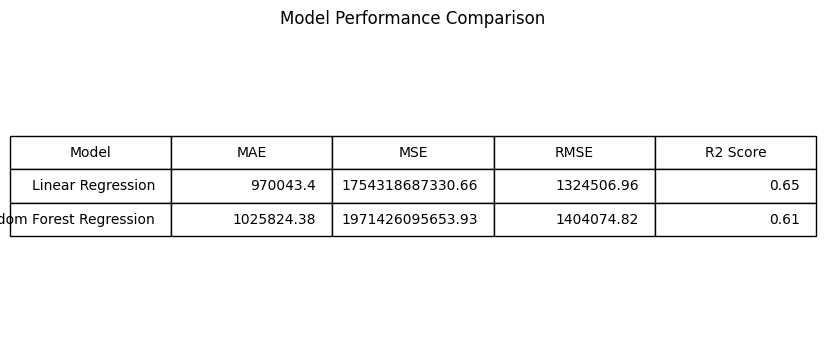

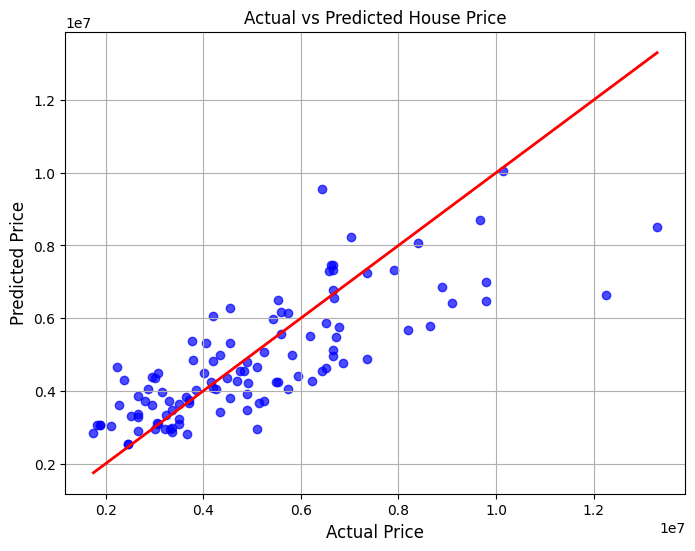

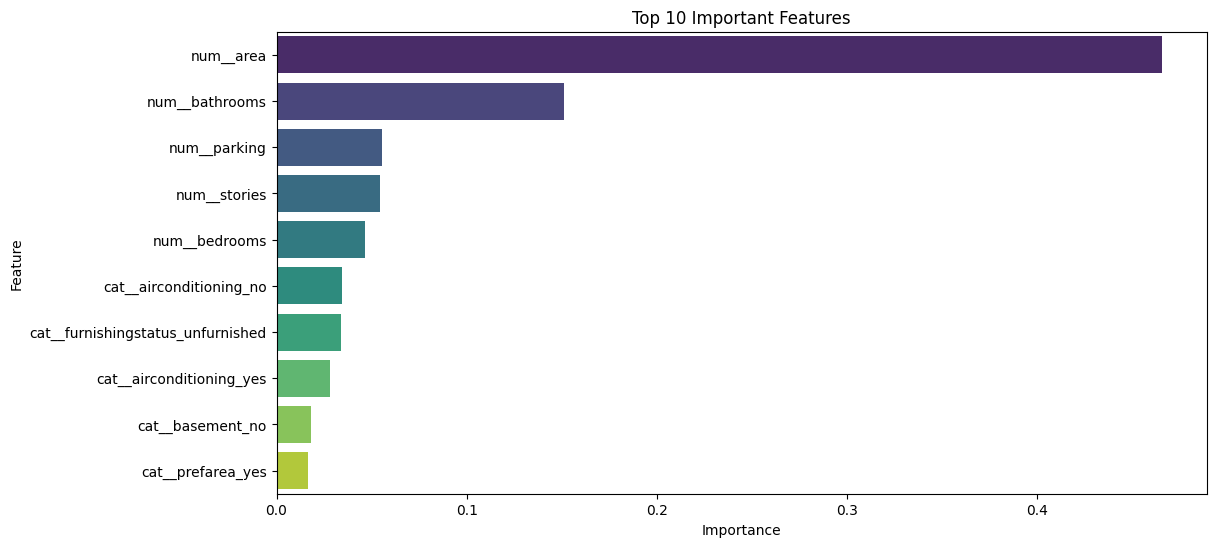

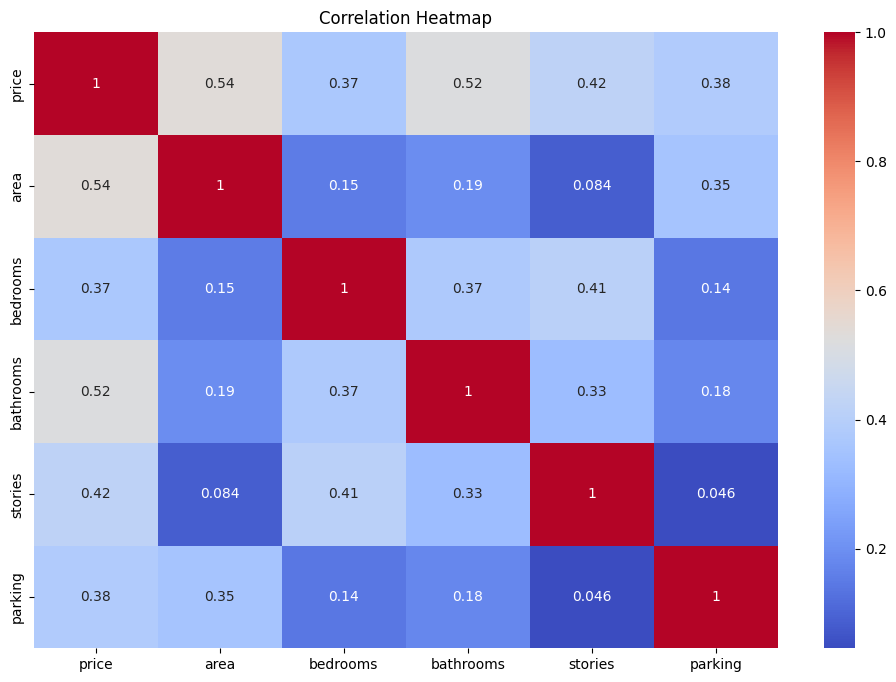


Pipeline Saved Successfully
Pipeline Loaded Successfully

Enter House Details



Area :  5000
Bedrooms :  2
Bathrooms :  2
Stories :  2
Mainroad (yes/no) :  yes
Guestroom (yes/no) :  yes
Basement (yes/no) :  yes
Hot Water Heating (yes/no) :  no
Air Conditioning (yes/no) :  no
Parking Spaces :  2
Preferred Area (yes/no) :  yes
Furnishing Status (furnished/semi-furnished/unfurnished) :  furnished




Predicted House Price
₹ 5,143,670.00


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [5]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("Housing.csv")

print(df.head())

print("\nDataset Shape :", df.shape)

print("\nColumns")

print(df.columns)

print("\nMissing Values")

print(df.isnull().sum())

# ============================================
# FEATURE & TARGET
# ============================================

X = df.drop("price", axis=1)

y = df["price"]

# ============================================
# NUMERICAL & CATEGORICAL COLUMNS
# ============================================

numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("\nNumerical Columns")

print(numerical_features)

print("\nCategorical Columns")

print(categorical_features)

# ============================================
# NUMERICAL PIPELINE
# ============================================

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(strategy="median")

        )

    ]

)

# ============================================
# CATEGORICAL PIPELINE
# ============================================

categorical_transformer = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(strategy="most_frequent")

        ),

        (

            "encoder",

            OneHotEncoder(handle_unknown="ignore")

        )

    ]

)

# ============================================
# COLUMN TRANSFORMER
# ============================================

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_transformer,

            numerical_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ]

)

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("\nTraining Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

# ============================================
# LINEAR REGRESSION PIPELINE
# ============================================

linear_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "model",

            LinearRegression()

        )

    ]

)

# ============================================
# RANDOM FOREST PIPELINE
# ============================================

rf_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "model",

            RandomForestRegressor(

                n_estimators=100,

                random_state=42

            )

        )

    ]

)

print("\nPipeline Created Successfully")

# ============================================
# TRAIN LINEAR REGRESSION
# ============================================

print("="*60)
print("TRAINING LINEAR REGRESSION")
print("="*60)

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

print("Linear Regression Model Trained Successfully")


# ============================================
# TRAIN RANDOM FOREST
# ============================================

print("\n" + "="*60)
print("TRAINING RANDOM FOREST")
print("="*60)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("Random Forest Model Trained Successfully")


# ============================================
# MODEL EVALUATION FUNCTION
# ============================================

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    print(f"Mean Absolute Error  : {mae:,.2f}")

    print(f"Mean Squared Error   : {mse:,.2f}")

    print(f"Root Mean Square Error : {rmse:,.2f}")

    print(f"R² Score             : {r2:.4f}")

    return [model_name, mae, mse, rmse, r2]


# ============================================
# EVALUATE BOTH MODELS
# ============================================

linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

rf_result = evaluate_model(
    "Random Forest Regression",
    y_test,
    rf_pred
)


# ============================================
# COMPARISON TABLE
# ============================================

results = pd.DataFrame(

    [linear_result, rf_result],

    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]

)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results)


# ============================================
# BEST MODEL
# ============================================

best_model = results.loc[
    results["R2 Score"].idxmax()
]

print("\n")
print("="*60)

print("BEST MODEL")

print("="*60)

print(best_model)


# ============================================
# DISPLAY RESULTS NICELY
# ============================================

plt.figure(figsize=(8,4))

plt.axis("off")

table = plt.table(
    cellText=results.round(2).values,
    colLabels=results.columns,
    loc="center"
)

table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(1.3,2)

plt.title("Model Performance Comparison")

plt.show()

# ============================================
# IMPORT JOBLIB
# ============================================

import joblib

# ============================================
# ACTUAL VS PREDICTED
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred,
            color="blue",
            alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price",fontsize=12)

plt.ylabel("Predicted Price",fontsize=12)

plt.title("Actual vs Predicted House Price")

plt.grid(True)

plt.show()

# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = rf_pipeline.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Important Features")

plt.show()

# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

sns.heatmap(

    numeric_df.corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Heatmap")

plt.show()

# ============================================
# SAVE MODEL
# ============================================

joblib.dump(

    rf_pipeline,

    "house_price_pipeline.pkl"

)

print("\nPipeline Saved Successfully")

# ============================================
# LOAD MODEL
# ============================================

loaded_pipeline = joblib.load(
    "house_price_pipeline.pkl"
)

print("Pipeline Loaded Successfully")

# ============================================
# USER INPUT
# ============================================

print("\nEnter House Details\n")

area = float(input("Area : "))

bedrooms = int(input("Bedrooms : "))

bathrooms = int(input("Bathrooms : "))

stories = int(input("Stories : "))

mainroad = input("Mainroad (yes/no) : ")

guestroom = input("Guestroom (yes/no) : ")

basement = input("Basement (yes/no) : ")

hotwaterheating = input(
    "Hot Water Heating (yes/no) : "
)

airconditioning = input(
    "Air Conditioning (yes/no) : "
)

parking = int(input("Parking Spaces : "))

prefarea = input(
    "Preferred Area (yes/no) : "
)

furnishingstatus = input(

    "Furnishing Status (furnished/semi-furnished/unfurnished) : "

)

# ============================================
# CREATE DATAFRAME
# ============================================

user_input = pd.DataFrame({

    "area":[area],

    "bedrooms":[bedrooms],

    "bathrooms":[bathrooms],

    "stories":[stories],

    "mainroad":[mainroad],

    "guestroom":[guestroom],

    "basement":[basement],

    "hotwaterheating":[hotwaterheating],

    "airconditioning":[airconditioning],

    "parking":[parking],

    "prefarea":[prefarea],

    "furnishingstatus":[furnishingstatus]

})

# ============================================
# PREDICT
# ============================================

prediction = loaded_pipeline.predict(user_input)

print("\n")

print("="*50)

print("Predicted House Price")

print("="*50)

print(f"₹ {prediction[0]:,.2f}")

from sklearn import set_config

set_config(display="diagram")

rf_pipeline